<a href="https://colab.research.google.com/github/sergey-kravchenko-km/KM_jupyterlabs/blob/main/KM_LB8_Kravchenko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Лабораторная работа 8. Обход бинарного дерева поиска. Поиск максимального и минимального значений**

Кравченко Сергей
1 курс 5 группа



## **Задание 8.1. Центрированный обход бинарного дерева поиска**

1. **Дополните и переопределите** классы `BinaryTree` , `BinaryNode`,
`EmptyNode` из Лабораторной работы 7 за счет определения нового метода
`lcr(self)` , реализующего центрированный обход бинарного дерева поиска.
Рекомендации по выполнению представлены в лекции к теме *Бинарное дерево
поиска. Реализация на основе ООП.*

Результатом вызова метода `lcr` для экземпляра класса `BinaryTree` должен быть
список значений вершин дерева, отсортированных по возрастанию.

2. **Создайте** список `source_data` из случайных чисел, равномерно
распределенных на отрезке $[0,100]$. **Постройте** бинарное дерево поиска по
списку случайных чисел и **выполните** центрированный обход дерева с
помощью метода `lcr` .

3. **Изобразите** график по точкам, ординаты которых заданы списком
`source_data` . В этой же графической области **изобразите** график по точкам,
одинаты которых заданы списком, результатом центрированного обхода
бинарного дерева поиска.

In [ ]:
class BinaryTree:
    def __init__(self):
        BinaryNode.numberOfNodes = 0 # Счётчик узлов (статическая переменная)
        self.root = EmptyNode()  # Корень дерева — пустой узел

    def __repr__(self):
        return repr(self.root) # Представление дерева через корневой узел

    def insert(self, value):
        self.root = self.root.insert(value)    # Вставка значения через корень

    def __contains__(self, value):
        return value in self.root # Проверка наличия значения

    def __len__(self):
        return len(self.root)   # Количество узлов в дереве

    def lcr(self):
        return self.root.lcr()

In [ ]:
class BinaryNode:
    def __init__(self, left, value, right):
        self.left = left  # Левый потомок
        self.value = value  # Значение узла
        self.right = right # Правый потомок
        BinaryNode.numberOfNodes += 1 # Увеличиваем счётчик узлов

    def __repr__(self):
        return f'({self.left}, {self.value}, {self.right})'

    def insert(self, value):
        if value < self.value:
            self.left = self.left.insert(value)  # Вставка в левое поддерево
        else:
           self.right = self.right.insert(value) # Вставка в правое поддерево
        return self # Возвращает текущий узел (для поддержки цепочки)

    def __contains__(self, value):
        if value==self.value:
            return True
        elif value<self.value:
            return value in self.left  # Поиск слева
        else:
            return value in self.right # Поиск справа

    def __len__(self):
        return self.numberOfNodes # Возвращает общее число узлов (статическое)

    def lcr(self):
        result = []
        if self.left is not None:  # Если есть левое поддерево, обходим его
            result += self.left.lcr()
        result.append(self.value)  # Добавляем значение текущего узла
        if self.right is not None:  # Если есть правое поддерево, обходим его
            result += self.right.lcr()
        return result

In [ ]:
class EmptyNode:
    def __repr__(self):
        return '*'

    def insert(self, value):
        return BinaryNode(self, value, self)  # Создаёт новый узел на месте пустого

    def __contains__(self, value):
        return False  # В пустом узле ничего нет

    def __len__(self):
        return 0 # Пустой узел не учитывается в длине

    def lcr(self):
        return []

### **Рекомендации по выполнению Задания 8.1**

In [ ]:
import matplotlib.pyplot as plt
import random as rnd

Cоздадим список из $10^3$ случайных чисел, равномерно распределенных на отрезке $[0,100]$
, с помощью функции `uniform` из модуля `random`

In [ ]:
source_data = [rnd.uniform(0,100) for i in range(10**3)]

Построим бинарное дерево поиска на основе списка `source_data`

In [ ]:
tree = BinaryTree()
for i in source_data:
    tree.insert(i)

Выполним центрированный обход созданного бинарного дерева `tree`

In [ ]:
sorted_data = tree.lcr()

Для проверки корректности обхода изобразим в одной графической области
значения исходного списка и результирующего списка после обхода дерева

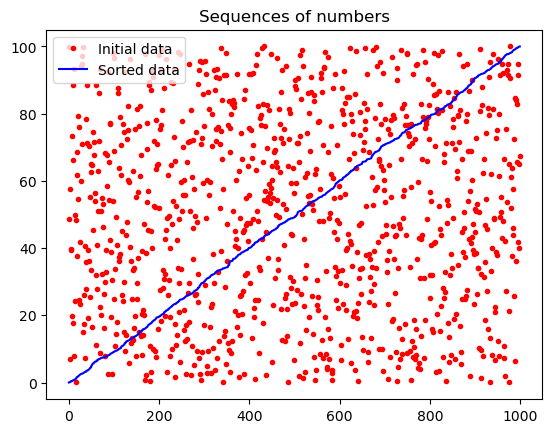

In [ ]:
plt.plot(source_data,'r.', label='Initial data')
plt.plot(sorted_data,color='blue',label='Sorted data')
plt.title('Sequences of numbers')
plt.legend()

## **Задание 8.2. Нахождение минимального и максимального значения**

**Доопределите или переопределите** классы `BinaryTree` , `BinaryNode` ,
`EmptyNode` за счет определения методов `min(self)` и `max(self)` для
нахождения минимального и максимального значений в дереве, соответственно.
Рекомендации по выполнению представлены в лекции к теме *Бинарное дерево поиска. Реализация на основе ООП.*

**Протестируйте** корректность выполнения методов `min` и `max` для дерева `tree` ,
созданного в Задании 8.1.

In [ ]:
class BinaryTree:
    def __init__(self):
        BinaryNode.numberOfNodes = 0 # Счётчик узлов (статическая переменная)
        self.root = EmptyNode()  # Корень дерева — пустой узел

    def __repr__(self):
        return repr(self.root) # Представление дерева через корневой узел

    def insert(self, value):
        self.root = self.root.insert(value)    # Вставка значения через корень

    def __contains__(self, value):
        return value in self.root # Проверка наличия значения

    def __len__(self):
        return len(self.root)   # Количество узлов в дереве

    def lcr(self):
        return self.root.lcr()

    def min(self):
        return self.root.min()

    def max(self):
        return self.root.max()

In [ ]:
class BinaryNode:
    def __init__(self, left, value, right):
        self.left = left  # Левый потомок
        self.value = value  # Значение узла
        self.right = right # Правый потомок
        BinaryNode.numberOfNodes += 1 # Увеличиваем счётчик узлов

    def __repr__(self):
        return f'({self.left}, {self.value}, {self.right})'

    def insert(self, value):
        if value < self.value:
            self.left = self.left.insert(value)  # Вставка в левое поддерево
        else:
           self.right = self.right.insert(value) # Вставка в правое поддерево
        return self # Возвращает текущий узел (для поддержки цепочки)

    def __contains__(self, value):
        if value==self.value:
            return True
        elif value<self.value:
            return value in self.left  # Поиск слева
        else:
            return value in self.right # Поиск справа

    def __len__(self):
        return self.numberOfNodes # Возвращает общее число узлов (статическое)

    def lcr(self):
        result = []
        if self.left is not None:  # Если есть левое поддерево, обходим его
            result += self.left.lcr()
        result.append(self.value)  # Добавляем значение текущего узла
        if self.right is not None:  # Если есть правое поддерево, обходим его
            result += self.right.lcr()
        return result

    def min(self):
        if isinstance(self.left, EmptyNode):  # Если левого поддерева нет
            return self.value  # Текущий узел — минимальный
        else:
            return self.left.min()
    def max(self):
        if isinstance(self.right, EmptyNode):  # Если левого поддерева нет
            return self.value  # Текущий узел — минимальный
        else:
            return self.right.max() # Текущий узел — max

In [ ]:
class EmptyNode:
    def __repr__(self):
        return '*'

    def insert(self, value):
        return BinaryNode(self, value, self)  # Создаёт новый узел на месте пустого

    def __contains__(self, value):
        return False  # В пустом узле ничего нет

    def __len__(self):
        return 0 # Пустой узел не учитывается в длине

    def lcr(self):
        return []

    def min(self):
        return

    def max(self):
        return

In [ ]:
source_data1 = [rnd.randrange(100) for i in range(10)]

In [ ]:
tree = BinaryTree()
for i in source_data1:
    tree.insert(i)

In [ ]:
print(tree.min())
print(tree.max())

11
91


## **Задание 8.3. Создание модуля**

**Напишите** модуль binaryTree.py на основе созданных классов.

**Напишите** строки документации для классов BinaryTree , BinaryNode ,
EmptyNode и для каждого метода классов.

**Протестируйте** работу созданного модуля на примерах.

In [ ]:
import binaryTree

In [ ]:
print(binaryTree.BinaryTree.__doc__)
print("\n",binaryTree.BinaryNode.__doc__)
print("\n",binaryTree.EmptyNode.__doc__)


        Реализация бинарного дерева поиска (BST).
        Является контейнером, в котором хранятся значения написанных класса BinaryNode и EmptyNode.
    Attributes:
        root (BinaryNode | EmptyNode): Корневой узел дерева. По умолчанию — пустой узел.
   

 Узел бинарного дерева поиска.

    Attributes:
        value: Значение узла.
        left (BinaryNode | EmptyNode): Левый потомок.
        right (BinaryNode | EmptyNode): Правый потомок.
    

 Пустой узел, обозначающий отсутствие данных в дереве.


In [ ]:
print(binaryTree.BinaryTree.insert.__doc__)
print("\n",binaryTree.BinaryNode.insert.__doc__)
print("\n",binaryTree.EmptyNode.insert.__doc__)

Добавляет значение в бинарное дерево поиска.

        Args:
            value: Значение для вставки (должно поддерживать сравнение).
       

 Вставляет значение в поддерево с корнем в этом узле.

        Args:
            value: Значение для вставки.

        Returns:
            BinaryNode: Текущий узел (self) или новый узел, если вставка в пустое поддерево.
        

 Создает новый узел с заданным значением.

        Args:
            value: Значение для вставки.

        Returns:
            BinaryNode: Новый узел.
        


In [ ]:
print(binaryTree.BinaryTree.min.__doc__)
print("\n",binaryTree.BinaryNode.lcr.__doc__)
print("\n",binaryTree.EmptyNode.__len__.__doc__)

Возвращает минимальное значение в бинарном дереве поиска или None

 Возвращает список значений в порядке центрированного обхода (LCR).

        Returns:
            list: Список значений в порядке 'левый-корень-правый'.
        

 None


In [ ]:
tree = binaryTree.BinaryTree()
for i in range(1,100):
    tree.insert(i)

In [ ]:
print(tree.min(),tree.max(),tree.__len__())
print(tree)
print(tree.lcr())

1 99 99
(*, 1, (*, 2, (*, 3, (*, 4, (*, 5, (*, 6, (*, 7, (*, 8, (*, 9, (*, 10, (*, 11, (*, 12, (*, 13, (*, 14, (*, 15, (*, 16, (*, 17, (*, 18, (*, 19, (*, 20, (*, 21, (*, 22, (*, 23, (*, 24, (*, 25, (*, 26, (*, 27, (*, 28, (*, 29, (*, 30, (*, 31, (*, 32, (*, 33, (*, 34, (*, 35, (*, 36, (*, 37, (*, 38, (*, 39, (*, 40, (*, 41, (*, 42, (*, 43, (*, 44, (*, 45, (*, 46, (*, 47, (*, 48, (*, 49, (*, 50, (*, 51, (*, 52, (*, 53, (*, 54, (*, 55, (*, 56, (*, 57, (*, 58, (*, 59, (*, 60, (*, 61, (*, 62, (*, 63, (*, 64, (*, 65, (*, 66, (*, 67, (*, 68, (*, 69, (*, 70, (*, 71, (*, 72, (*, 73, (*, 74, (*, 75, (*, 76, (*, 77, (*, 78, (*, 79, (*, 80, (*, 81, (*, 82, (*, 83, (*, 84, (*, 85, (*, 86, (*, 87, (*, 88, (*, 89, (*, 90, (*, 91, (*, 92, (*, 93, (*, 94, (*, 95, (*, 96, (*, 97, (*, 98, (*, 99, *)))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 

In [ ]:
tree = binaryTree.BinaryTree()
source_data0 = "asjfblsdbaajerweooerygdnj"
for i in source_data0:
    tree.insert(i)
print(tree.min(),tree.max(),tree.__len__())
print(tree)
print(tree.lcr())

a y 25
(*, a, (((((*, a, (*, a, *)), b, ((*, b, *), d, ((*, d, *), e, (*, e, (*, e, *))))), f, (*, g, *)), j, ((*, j, (*, j, *)), l, (((*, n, *), o, (*, o, *)), r, (*, r, *)))), s, (*, s, (*, w, (*, y, *)))))
['a', 'a', 'a', 'b', 'b', 'd', 'd', 'e', 'e', 'e', 'f', 'g', 'j', 'j', 'j', 'l', 'n', 'o', 'o', 'r', 'r', 's', 's', 'w', 'y']


In [ ]:
tree = binaryTree.BinaryTree()
source_data0 = [1,2,4.5,5,3,2,6,2,61,43,32,32,324,6]
for i in source_data0:
    tree.insert(i)
print(tree.min(),tree.max(),tree.__len__())

1 324 14


In [ ]:
print(tree)

(*, 1, (*, 2, (((*, 2, (*, 2, *)), 3, *), 4.5, (*, 5, (*, 6, ((((*, 6, *), 32, (*, 32, *)), 43, *), 61, (*, 324, *)))))))


In [ ]:
print(tree.lcr())

[1, 2, 2, 2, 3, 4.5, 5, 6, 6, 32, 32, 43, 61, 324]


## **Задание 8.4 Примеры пользовательских классов**

**Первый класс**

In [ ]:
import time

class Date():
    def __init__(self, day=11, month=5, year=2024):
        self.day = day; self.month = month; self.year = year # Date in the origin
    @classmethod
    def now(cls):
        t = time.localtime()
        return cls(t.tm_mday, t.tm_mon, t.tm_year) # Date in nowadays
    def __repr__(self):
        return f'{self.day}.{self.month}.{self.year}' # represence of Date()

a = Date.now()
b = Date()
a,b

(21.5.2025, 11.5.2024)

**Второй класс**

In [ ]:
from abc import ABC, abstractmethod

class AbstractClass(ABC):
    @abstractmethod
    def abstract_method(self):
        """Этот метод должен быть реализован в подклассах."""
        pass

    def regular_method(self):
        print("Это обычный метод, он уже реализован.")
        return 249


class ConcreteClass(AbstractClass):
    def abstract_method(self):
        x = 20
        y = 25
        print("Реализация абстрактного метода в подклассе.",x*y)

# Пример использования
obj = ConcreteClass()
obj.abstract_method()  # Выведет: Реализация абстрактного метода в подклассе.
obj.regular_method()   # Выведет: Это обычный метод, он уже реализован.

# Попытка создать экземпляр абстрактного класса вызовет ошибку:
# example = AbstractClassExample()  # TypeError: Can't instantiate abstract class AbstractClassExample with abstract method abstract_method

Реализация абстрактного метода в подклассе. 500
Это обычный метод, он уже реализован.


249

**Третий класс**

In [ ]:
import math
class Class1:
    def __init__(self):
        self._x = None

    @property # с методом можно будет работать, как с атрибутом
    def x_squared(self):
        """squared value of class attribute"""
        if self._x is None:
            return None
        else:
            return self._x**2

    @x_squared.setter
    def x_squared(self, value):
        self._x = math.sqrt(value)

    @x_squared.deleter
    def x_squared(self):
        print('NotImplemented')

a = Class1()
print(a.x_squared)
a.x_squared = 49
print(a._x)
del a.x_squared

None
7.0
NotImplemented
